#Preparación del conjunto de datos

Este notebook realiza la **preparación del conjunto de datos (X, y)** a partir de imágenes correspondientes a tres clases del juego "Piedra, Papel o Tijera". Las imágenes están organizadas por categoría en carpetas y son procesadas para crear matrices de entrada y etiquetas para el entrenamiento de modelos de aprendizaje profundo.

Las principales etapas que se llevan a cabo son:

- Carga de imágenes desde las carpetas `dataset/piedra`, `dataset/papel` y `dataset/tijera`
- Visualización de muestras aleatorias de cada clase
- Redimensionamiento de imágenes a 64x64 píxeles
- Asignación de etiquetas numéricas a cada clase (0: papel, 1: tijera, 2: piedra)
- División en conjuntos de entrenamiento y prueba
- Normalización de los datos de entrada
- Codificación one-hot de las etiquetas de salida
- Almacenamiento de los datos procesados en archivos `.npy` para uso posterior

>  Este procesamiento es fundamental para preparar adecuadamente los datos antes de entrenar un modelo de clasificación con redes neuronales.

# Datos de entrenamiento y validación

In [2]:
import glob

In [3]:
lista_papel = glob.glob('dataset_sinMediaPipe/papel/*.jpg')
lista_tijera = glob.glob('dataset_sinMediaPipe/tijera/*.jpg')
lista_piedra = glob.glob('dataset_sinMediaPipe/piedra/*.jpg')


In [4]:
# Librerias de ayuda
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2 as cv
from numpy import random


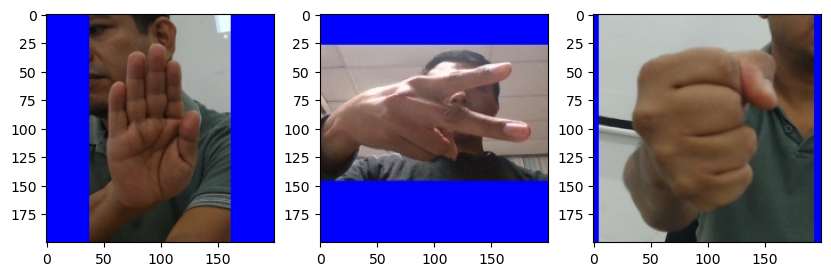

In [5]:
plt.figure(figsize=(10,5))

plt.subplot(1, 3, 1)
img = cv.imread(lista_papel[random.randint(len(lista_papel))])
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB) , cmap="binary")

plt.subplot(1, 3, 2)
img = cv.imread(lista_tijera[random.randint(len(lista_tijera))])
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB) , cmap="binary")

plt.subplot(1, 3, 3)
img = cv.imread(lista_piedra[random.randint(len(lista_piedra))])
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB) , cmap="binary")


plt.show()

In [6]:
print(len(lista_papel), len(lista_tijera), len(lista_piedra))

516 557 536


In [7]:
data_dict={'papel_imagenes' :   lista_papel ,
           'tijera_imagenes'  : lista_tijera,
           'piedra_imagenes' : lista_piedra}

In [8]:
labels_dict={'papel_imagenes' :   0 ,
           'tijera_imagenes'  : 1,
           'piedra_imagenes' : 2}

In [9]:
import cv2
import numpy as np

In [10]:
#revisar
data_dict.items()

dict_items([('papel_imagenes', ['dataset_sinMediaPipe/papel\\image_O_111017453823.jpg', 'dataset_sinMediaPipe/papel\\image_P_004206016039.jpg', 'dataset_sinMediaPipe/papel\\image_P_004207777570.jpg', 'dataset_sinMediaPipe/papel\\image_P_004212053574.jpg', 'dataset_sinMediaPipe/papel\\image_P_004213195296.jpg', 'dataset_sinMediaPipe/papel\\image_P_004215345707.jpg', 'dataset_sinMediaPipe/papel\\image_P_004222857781.jpg', 'dataset_sinMediaPipe/papel\\image_P_004225151351.jpg', 'dataset_sinMediaPipe/papel\\image_P_004226385128.jpg', 'dataset_sinMediaPipe/papel\\image_P_004229509098.jpg', 'dataset_sinMediaPipe/papel\\image_P_004237983571.jpg', 'dataset_sinMediaPipe/papel\\image_P_004308146968.jpg', 'dataset_sinMediaPipe/papel\\image_P_004320223310.jpg', 'dataset_sinMediaPipe/papel\\image_P_004331068377.jpg', 'dataset_sinMediaPipe/papel\\image_P_004335068773.jpg', 'dataset_sinMediaPipe/papel\\image_P_004338871210.jpg', 'dataset_sinMediaPipe/papel\\image_P_004345164279.jpg', 'dataset_sinMedi

In [11]:
X = []
y = []

for label , lista_images   in data_dict.items():
  print(label)
  for image in lista_images:
    img = cv2.imread( image  )
    img_resize = cv2.resize( img, (64,64) )
    X.append(img_resize)
    y.append( labels_dict[label] )

papel_imagenes


tijera_imagenes
piedra_imagenes


In [12]:
import numpy as np

X = np.array(X)
y = np.array(y)


In [13]:
print( X.shape)
print( y.shape)


(1609, 64, 64, 3)
(1609,)


In [14]:
from numpy import asarray
from numpy import save

In [15]:
save('dataset_sinMediaPipe/X_hand.npy', X)
save('dataset_sinMediaPipe/y_hand.npy', y)


# Datos de test

In [16]:
lista_papel_test= glob.glob('dataset_test/papel/*.jpg')
lista_tijera_test = glob.glob('dataset_test/tijera/*.jpg')
lista_piedra_test = glob.glob('dataset_test/piedra/*.jpg')


In [17]:
print(len(lista_papel_test), len(lista_tijera_test), len(lista_piedra_test))

56 57 62


In [18]:
data_dict_test={'papel_imagenes' :   lista_papel_test,
           'tijera_imagenes'  : lista_tijera_test,
           'piedra_imagenes' : lista_piedra_test}

In [19]:
data_dict_test.items()

dict_items([('papel_imagenes', ['dataset_test/papel\\image_P_102404632055.jpg', 'dataset_test/papel\\image_P_102408076113.jpg', 'dataset_test/papel\\image_P_102444079107.jpg', 'dataset_test/papel\\image_P_102446550876.jpg', 'dataset_test/papel\\image_P_102448158614.jpg', 'dataset_test/papel\\image_P_102451281389.jpg', 'dataset_test/papel\\image_P_102453909023.jpg', 'dataset_test/papel\\image_P_102459723127.jpg', 'dataset_test/papel\\image_P_102500709798.jpg', 'dataset_test/papel\\image_P_102502632406.jpg', 'dataset_test/papel\\image_P_102504614973.jpg', 'dataset_test/papel\\image_P_103525894855.jpg', 'dataset_test/papel\\image_P_103528359545.jpg', 'dataset_test/papel\\image_P_103538929081.jpg', 'dataset_test/papel\\image_P_103555641570.jpg', 'dataset_test/papel\\image_P_103600087739.jpg', 'dataset_test/papel\\image_P_103607723742.jpg', 'dataset_test/papel\\image_P_103608720416.jpg', 'dataset_test/papel\\image_P_103611072215.jpg', 'dataset_test/papel\\image_P_103614669292.jpg', 'dataset

In [20]:
X_test = []
y_test = []

for label , lista_images   in data_dict_test.items():
  print(label)
  for image in lista_images:
    img = cv2.imread( image  )
    img_resize = cv2.resize( img, (64,64) )
    X_test.append(img_resize)
    y_test.append( labels_dict[label] )

papel_imagenes
tijera_imagenes
piedra_imagenes


In [21]:
import numpy as np

X_test = np.array(X_test)
y_test = np.array(y_test)
print( X_test.shape)
print( y_test.shape)


(175, 64, 64, 3)
(175,)


In [22]:
save('dataset_test/X_hand_test.npy', X_test)
save('dataset_test/y_hand_test.npy', y_test)

In [23]:
!ls dataset_test

'ls' is not recognized as an internal or external command,
operable program or batch file.
